# Data Profiling 
This section assesses the dataset's structure, quality, and potential issues.

**Data Loading & Date Parsing**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# load the csv file
df = pd.read_csv('../data/sudan.csv') 
# Add Country Column
df['Country'] = 'Sudan'
# create a dat from the year and DOY
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
#extracting a month from the year and the DOY
df['Month'] = df['Date'].dt.month
# Check the results
print(df[['YEAR', 'DOY',  'Month']].tail())



      YEAR  DOY  Month
4103  2026   86      3
4104  2026   87      3
4105  2026   88      3
4106  2026   89      3
4107  2026   90      3


**Summary Statistics & Missing-Value Report**

In [13]:
# Check how many rows and features columns we have
print("Data Shape:", df.shape) 
#  Handle NASA Sentinel Values
df.replace(-999, np.nan, inplace=True)
# Duplicate Check
duplicates = df.duplicated().sum()
print(f"Total Duplicate Rows Found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")


Data Shape: (4108, 15)
Total Duplicate Rows Found: 0


**Duplicate check**

0 duplicate rows were detected across all 4,108 observations.

Therefore, No data removal was required showing that each record in the Ethiopia dataset represents a unique observation.

In [14]:

# Generate the 5-number summary (count, mean, std, min, max)
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


**Statistical Interpretation of Climate Variables**

Temperature (T2M): Sudan is extremely hot, with an average temperature of 28.76°C. The daytime highs are scorching, averaging nearly 37°C and sometimes reaching a massive 45.96°C. However, the temperature has a very wide range throughout the year, dropping as low as 13.18°C during cooler months.

Daily Temp Change (T2M_RANGE): There is a huge difference between day and night temperatures. On average, the temperature drops by over 15°C when the sun goes down, and sometimes swings by more than 22°C in a single day.  This fast heating and cooling is exactly what happens in very dry, sandy areas.

Rainfall (PRECTOTCORR): Sudan is incredibly dry. Looking at the data, for most of the year (at least 75% of the time), there is absolutely zero rain. The daily average is less than 1 mm. However, just like other regions, it occasionally gets hit by a sudden, heavy storm, with the maximum rain reaching 66.49 mm in a single day.

Humidity and Wind (RH2M & WS2M): The air is very dry and crisp. The average humidity is only 31.4%, and it can drop as low as 4.69%. The wind is fairly strong and active, averaging 3.48 m/s, which is common in open, flat desert landscapes.

Air Pressure (PS): The pressure averages 96.35 kPa, which puts it somewhere in the middle compared to sea level and high mountain ranges.

In [15]:
# Check for Missing Values
print("\n--- Missing Value Count ---")
print(df.isna().sum())
missing_values = df.isna().sum()
missing_pct = (missing_values / len(df)) * 100


--- Missing Value Count ---
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


The missing value analysis shows the Ethiopia dataset contains 0% null values across all columns.

What this means for the analysis: Since no columns exceed the 5% threshold. We do not need to fill any gaps. 

**Outlier Detection & Basic Cleaning**



In [16]:
#  Z-Score Calculation
target_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
z_scores = np.abs(stats.zscore(df[target_cols].dropna()))

# Flagging outliers
outliers_count = (z_scores > 3).sum(axis=0)
print("Outlier counts per column (|Z| > 3):")
print(outliers_count)

Outlier counts per column (|Z| > 3):
[ 3  6  1 71  3  4  3]


**Outlier Detection**

In total we have 91 outliers across the given columns. 

It has been chosen to retain the 91 identified outliers because,

 In a climate dataset, extreme values represent important weather events like storms and heatwaves. Most of these outliers are in the Rainfall (PRECTOTCORR) column. This is expected because rain happens in sudden bursts, and these spikes are a real part of the average.

Out of 4,108 observations, these 91 outliers make up less than 0.5% of the data. Keeping them protects the natural variety of the climate record without hurting the accuracy of our trend analysis.

In [17]:
# Handling Strategy
# Forward-fill for weather variables to maintain time-series continuity
df[target_cols] = df[target_cols].ffill()

# Export Cleaned Data and the data folder is in gitignore
df.to_csv('../data/Sudan_clean.csv', index=False)

**Time Series Analysis**

***Monthly Temperature Trends (2015–2026)***

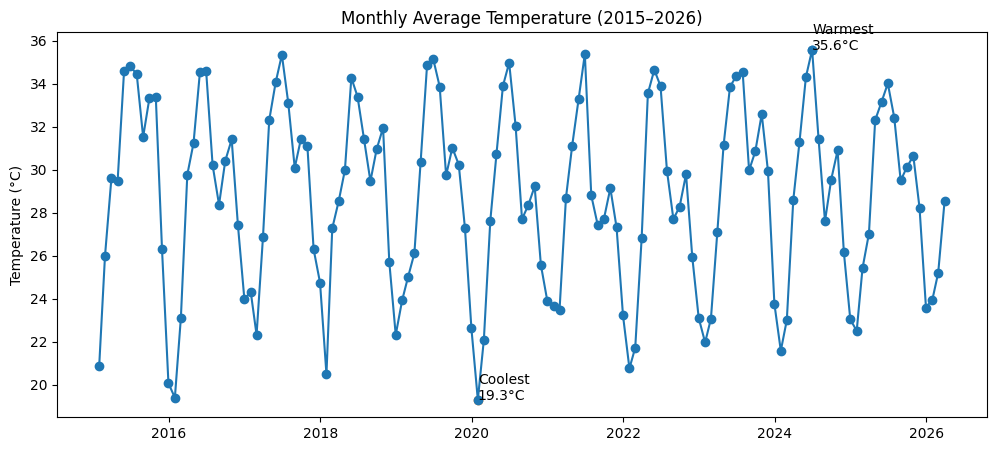

In [18]:
# Resample to monthly averages
monthly_temp = df.set_index('Date').resample('ME')['T2M'].mean().reset_index()

# Find warmest and coolest months
warmest = monthly_temp.loc[monthly_temp['T2M'].idxmax()]
coolest = monthly_temp.loc[monthly_temp['T2M'].idxmin()]

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], marker='o')

# Annotate
plt.scatter(warmest['Date'], warmest['T2M'])
plt.text(warmest['Date'], warmest['T2M'], f"Warmest\n{warmest['T2M']:.1f}°C")

plt.scatter(coolest['Date'], coolest['T2M'])
plt.text(coolest['Date'], coolest['T2M'], f"Coolest\n{coolest['T2M']:.1f}°C")

plt.title('Monthly Average Temperature (2015–2026)')
plt.ylabel('Temperature (°C)')
plt.show()

The line chart shows how the temperature moves up and down in a steady every year. The dataset captures a peak monthly temperature of 35.6°C and a minimum of 19.3°C, representing a substantial thermal range of over 16.0°C. the temperature patterns remain highly consistent across the 11-year observation period.

**Monthly Total Precipitation**

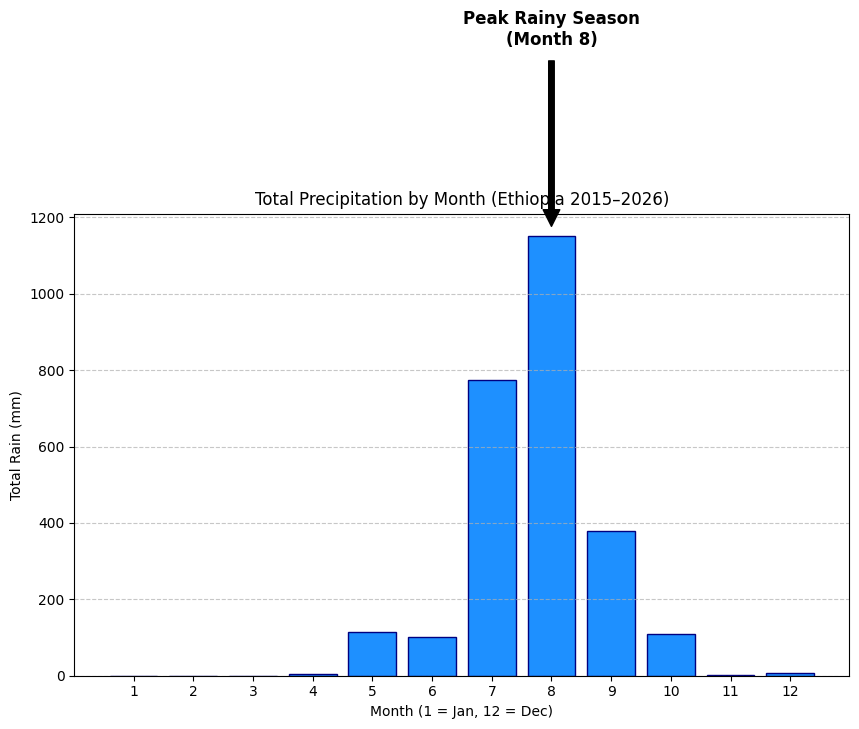

In [ ]:
# 1. Group by Month (1-12) to get the total rain for that month across all years
seasonal_rain = df.groupby('Month')['PRECTOTCORR'].sum().reset_index()

# 2. Find the peak month for annotation
peak_val = seasonal_rain['PRECTOTCORR'].max()
peak_month_num = seasonal_rain.loc[seasonal_rain['PRECTOTCORR'].idxmax(), 'Month']

# 3. Plotting
plt.figure(figsize=(10, 6))
# We use seasonal_rain['Month'] as the X-axis so we get 12 clean bars
plt.bar(seasonal_rain['Month'], seasonal_rain['PRECTOTCORR'], color='dodgerblue', edgecolor='navy')

# 4. Annotation (Identifying the peak)
plt.annotate(f'Peak Rainy Season\n(Month {int(peak_month_num)})', 
             xy=(peak_month_num, peak_val), 
             xytext=(peak_month_num, peak_val + 500),
             ha='center',
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, fontweight='bold')

plt.title('Total Precipitation by Month (Sudan 2015–2026)')
plt.xlabel('Month (1 = Jan, 12 = Dec)')
plt.ylabel('Total Rain (mm)')
plt.xticks(range(1, 13)) # Show every month number
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The bar chart shows that the majority of the year (months 1–5 and 10–12), precipitation is very low. however there is brief rainy season occurs, starting from july peaking sharply in August (Month 8). This confirms a highly arid region.

**Correlation & Relationship Analysis**

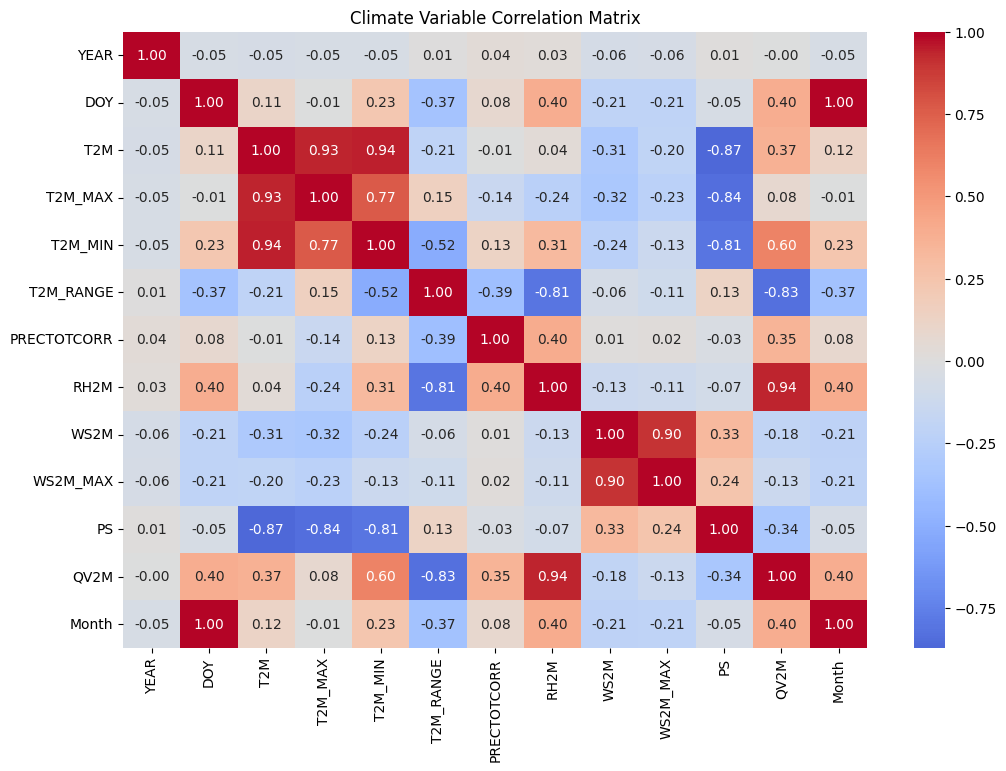

In [24]:
# Heatmap of correlations
plt.figure(figsize=(12, 8))
# We only select numeric columns to avoid errors with the Date or Country strings
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Climate Variable Correlation Matrix')
plt.show()

Based on the heatmap, here are the three most significant relationships in the dataset:

Humidity & Water Vapor (RH2M vs. QV2M): 0.94
A strong positive correlation. This indicates that increases in absolute atmospheric water vapor directly and strongly  relative humidity levels during the brief wet season.

Wind Speed (WS2M vs. WS2M_MAX): 0.90
A strong positive correlation demonstrating that higher baseline wind speeds reliably predict more intense maximum wind gusts..

Temperature Range vs. Humidity (T2M_RANGE vs. RH2M): -0.81
A strong negative correlation. Days with significant  temperature fluctuations are heavily associated with low atmospheric moisture. 

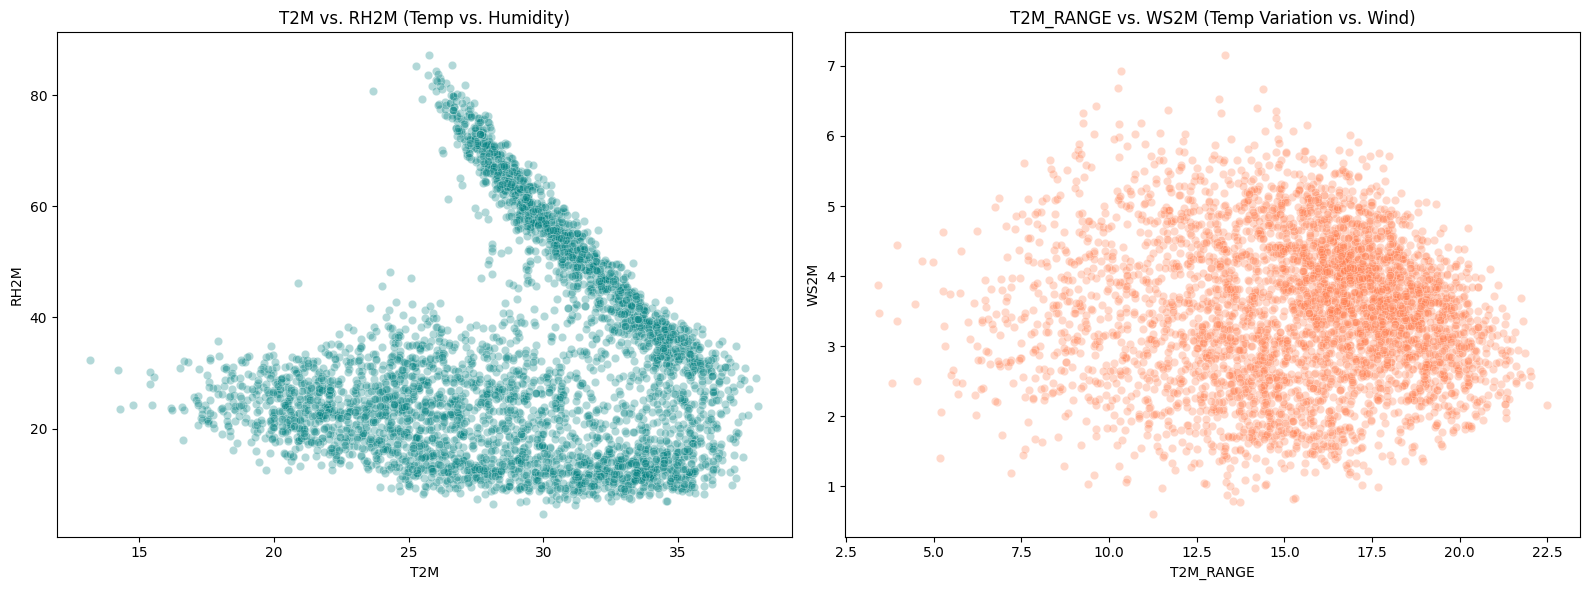

In [21]:
# Scatter plots for specific relationships
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Temperature vs Relative Humidity
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.3, ax=ax1, color='teal')
ax1.set_title('T2M vs. RH2M (Temp vs. Humidity)')

# Plot 2: Diurnal Range vs Wind Speed
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.3, ax=ax2, color='coral')
ax2.set_title('T2M_RANGE vs. WS2M (Temp Variation vs. Wind)')

plt.tight_layout()
plt.show()

Temperature vs. Humidity (Left): The scatter plot demonstrates a clear inverse relationship. The dense clustering in the lower-right quadrant indicates predominantly hot and arid baseline conditions. However, secondary cluster reveals that elevated humidity (associated with precipitation) is related with lower temperature profiles near 25°C.

Temp Range vs. Wind Speed (Right): The plot shows a highly dispersed, non-linear distribution. This suggests an absence of a strong  relationship; wind speeds in this region fluctuate independently of temperature variations.

**Distribution Analysis**

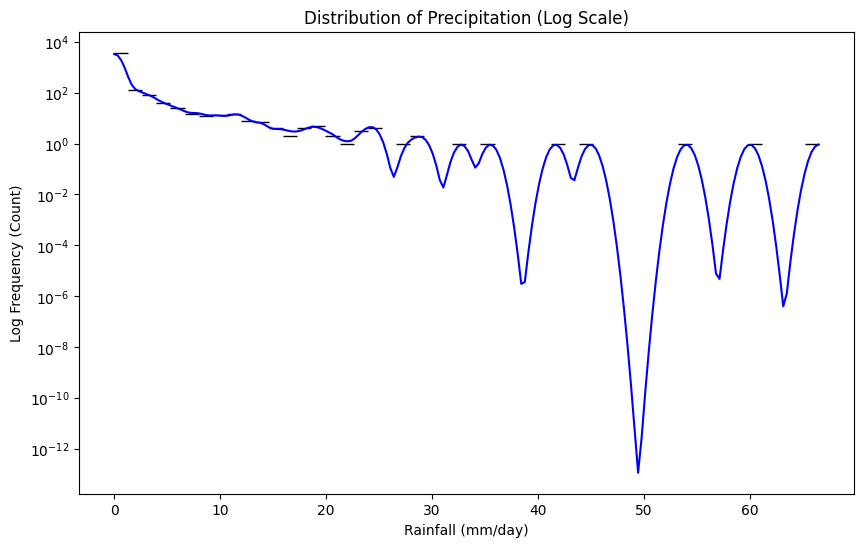

In [22]:
#  Distribution of Rainfall
plt.figure(figsize=(10, 6))
# log_scale=(False, True) means the counts (Y-axis) are log-transformed
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='blue', log_scale=(False, True))

plt.title('Distribution of Precipitation (Log Scale)')
plt.xlabel('Rainfall (mm/day)')
plt.ylabel('Log Frequency (Count)')
plt.show()

The histogram shows the extreme left-skewness. It indicates that the vast majority of observations record  zero precipitation. The extended right tail highlights the occurrence of rare, anomalous heavy rainfall events.

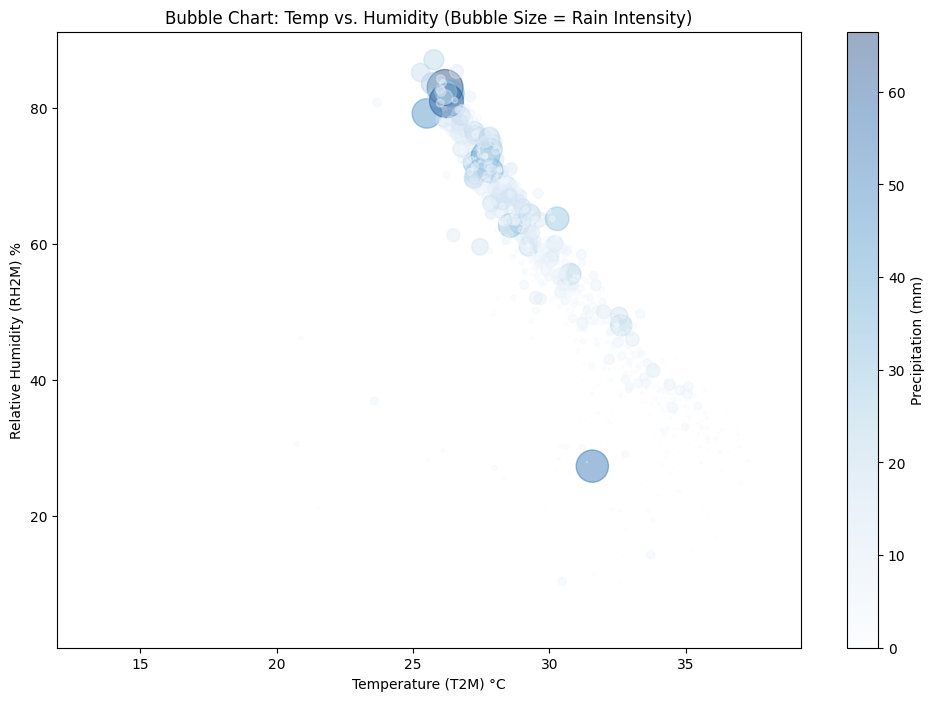

In [23]:
# Bubble Chart: T2M vs. RH2M (Size = PRECTOTCORR)
plt.figure(figsize=(12, 8))

# We multiply PRECTOTCORR by 10 to make the bubbles large enough to see
plt.scatter(df['T2M'], df['RH2M'], 
            s=df['PRECTOTCORR'] * 10, 
            alpha=0.4, 
            c=df['PRECTOTCORR'], 
            cmap='Blues')

plt.colorbar(label='Precipitation (mm)')
plt.title('Bubble Chart: Temp vs. Humidity (Bubble Size = Rain Intensity)')
plt.xlabel('Temperature (T2M) °C')
plt.ylabel('Relative Humidity (RH2M) %')
plt.show()

The bubble chart shows a sparse distribution of precipitation events. High-intensity rainfall (indicated by larger marker sizes) is strictly confined to a narrow atmospheric threshold: relative humidity approaching 80% combined with temperatures lower to approximately 26°C. 